# TP : Machine Learning Prédictif – Spaceship Titanic

### Objectif : Concevoir un système expert capable de déterminer la probabilité de transport d'un passager vers une dimension alternative en fonction de son profil.

## 1 - Chargement des données :

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_titanic = pd.read_csv("train.csv")
# df_test = pd.read_csv("test.csv")
# df_sample_submission = pd.read_csv("sample_submission.csv")

In [139]:
# df_titanic = pd.concat([df_train, df_test])
# df_titanic = df_titanic.reset_index(drop=True)

----



# 2 - Analyse exploratoire des données

In [140]:
df_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [141]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB




---



### 2-1 Analyse de la Target :

Transported indique le destin du passager après l’accident du vaisseau:
* True le passager a été transporté vers une autre dimension
* False le passager n’a pas été transporté

In [142]:
df_titanic["Transported"].value_counts()

,count
Transported,
True,4378
False,4315


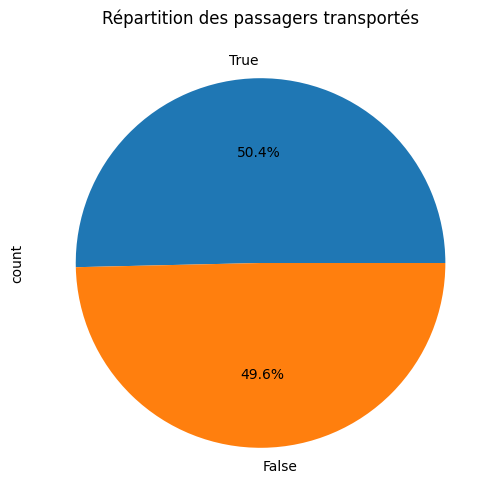

In [143]:
df_titanic["Transported"].value_counts().plot.pie(autopct="%1.1f%%",figsize=(6,6))

plt.title("Répartition des passagers transportés")
plt.show()

-> Les classes sont assez équilibrées



---



### 2-2 Corrélations Catégorielles :

* On regarde la relation entre HomePlanet et Transported :

Text(0, 0.5, 'Nombre de passagers')

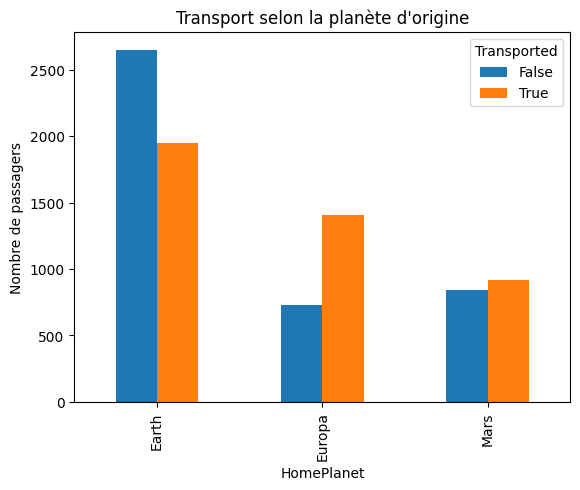

In [144]:
pd.crosstab(df_titanic["HomePlanet"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Transport selon la planète d'origine")
plt.ylabel("Nombre de passagers")



---



* On regarde la relation entre CryoSleep et Transported.

Text(0, 0.5, 'Nombre de passagers')

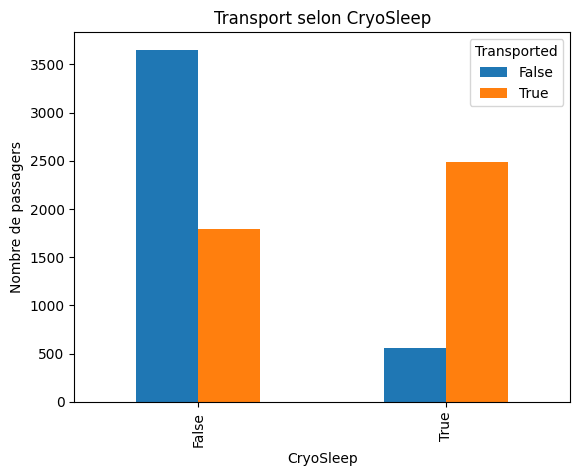

In [145]:
pd.crosstab(df_titanic["CryoSleep"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Transport selon CryoSleep")
plt.ylabel("Nombre de passagers")

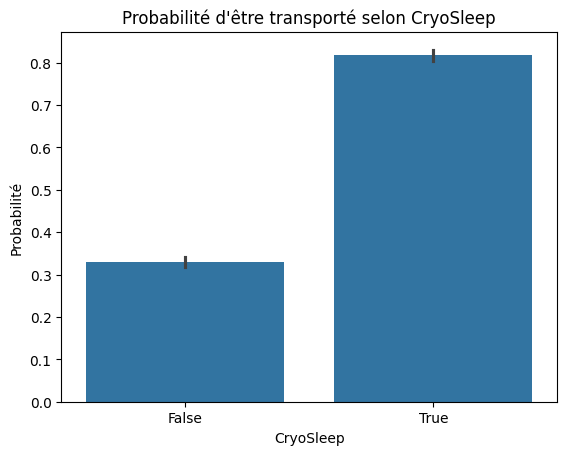

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_titanic.reset_index(drop=True), x="CryoSleep", y="Transported")

plt.title("Probabilité d'être transporté selon CryoSleep")
plt.ylabel("Probabilité")
plt.show()

On voit la probabilité d'être transporté en fonction de l'état de CryoSleep. les passagers en cryo-sommeil ont une probabilité beaucoup plus élevée d'être transportés.



---



* On regarde la relation entre Destination et Transported.

Text(0, 0.5, 'Nombre de passagers')

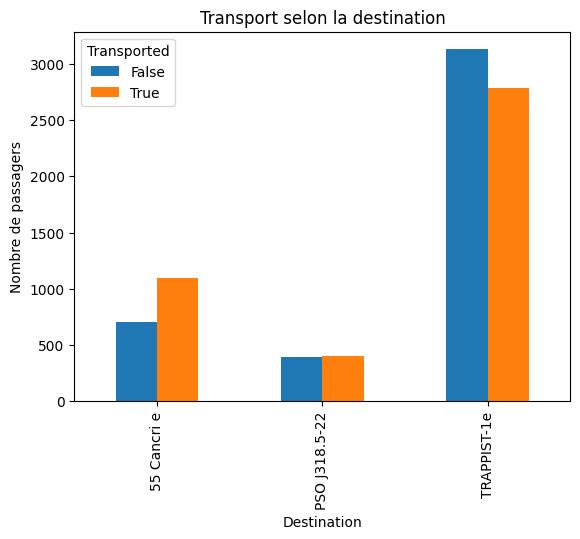

In [147]:
pd.crosstab(df_titanic["Destination"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Transport selon la destination")
plt.ylabel("Nombre de passagers")



---



* Extraction de Deck et Side :

In [148]:
df_titanic["Cabin"].head()

,Cabin
0,B/0/P
1,F/0/S
2,A/0/S
3,A/0/S
4,F/1/S


In [149]:
df_titanic[["Deck","Num","Side"]] = df_titanic["Cabin"].str.split("/", expand=True)

In [150]:
df_titanic[["Cabin","Deck","Num","Side"]].head()

,Cabin,Deck,Num,Side
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S




---



* Analyse de l'influence du pont :

Text(0, 0.5, 'Nombre de passagers')

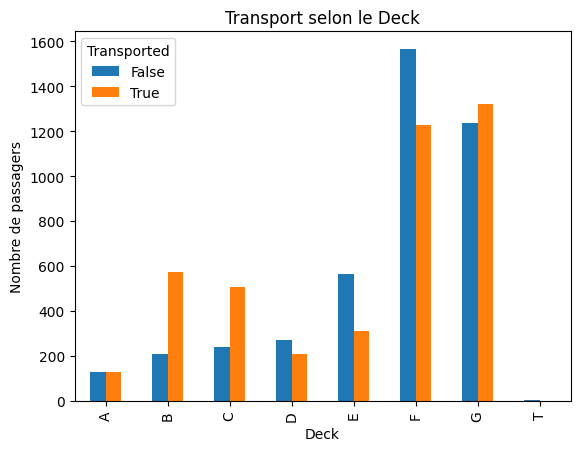

In [151]:
pd.crosstab(df_titanic["Deck"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Transport selon le Deck")
plt.ylabel("Nombre de passagers")

-> Chaque barre représente un deck du Titanic



---



* Analyse du side :

Text(0, 0.5, 'Nombre de passagers')

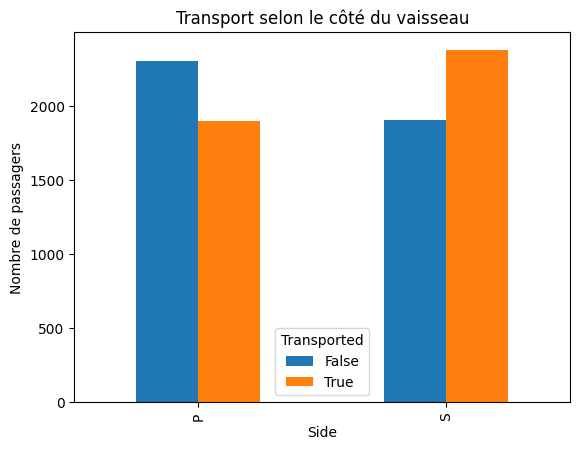

In [152]:
pd.crosstab(df_titanic["Side"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Transport selon le côté du vaisseau")
plt.ylabel("Nombre de passagers")

Ici on compare :
* P = Port -> côté gauche du titanic
* S = Starboard -> côté droit du titanic

### 2-3 •	Analyse Numérique :

* comparer la distribution de l’âge des passagers selon qu’ils ont été transportés ou non.

Text(0.5, 1.0, "Distribution de l'âge selon le statut de transport")

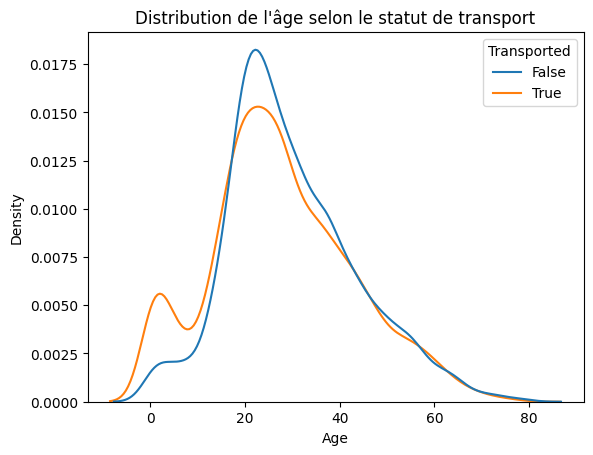

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_titanic, x="Age", hue="Transported")

plt.xlabel("Age")
plt.title("Distribution de l'âge selon le statut de transport")


In [154]:
df_titanic['over_15'] = df_titanic['Age'].apply(lambda x: '15_or_less' if x <= 15 else 'over_15')

In [155]:
# Convert 'Transported' to numeric for aggregation
df_titanic['Transported_numeric'] = df_titanic['Transported'].map({False: 0, True: 1})

age_group_summary = df_titanic.groupby('over_15').agg(
    count=('PassengerId', 'count'),
    mean_transported=('Transported_numeric', 'mean')
).reset_index()

display(age_group_summary)

,over_15,count,mean_transported
0,15_or_less,1240,0.648387
1,over_15,7453,0.479538


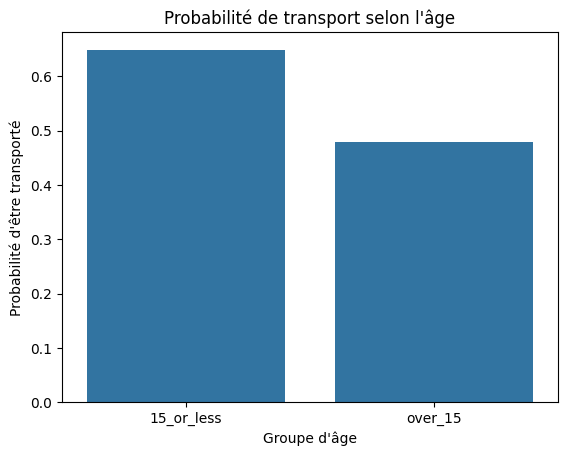

In [156]:
sns.barplot(data=age_group_summary, x="over_15", y="mean_transported")

plt.xlabel("Groupe d'âge")
plt.ylabel("Probabilité d'être transporté")
plt.title("Probabilité de transport selon l'âge")

plt.show()

On calcul la depense total par passager:

In [157]:
TotalSpend = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

df_titanic["TotalSpend"] = df_titanic[TotalSpend].sum(axis=1)

In [158]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PassengerId          8693 non-null   object 
 1   HomePlanet           8492 non-null   object 
 2   CryoSleep            8476 non-null   object 
 3   Cabin                8494 non-null   object 
 4   Destination          8511 non-null   object 
 5   Age                  8514 non-null   float64
 6   VIP                  8490 non-null   object 
 7   RoomService          8512 non-null   float64
 8   FoodCourt            8510 non-null   float64
 9   ShoppingMall         8485 non-null   float64
 10  Spa                  8510 non-null   float64
 11  VRDeck               8505 non-null   float64
 12  Name                 8493 non-null   object 
 13  Transported          8693 non-null   bool   
 14  Deck                 8494 non-null   object 
 15  Num                  8494 non-null   o

Text(0.5, 1.0, 'Dépense moyenne selon le statut de transport')

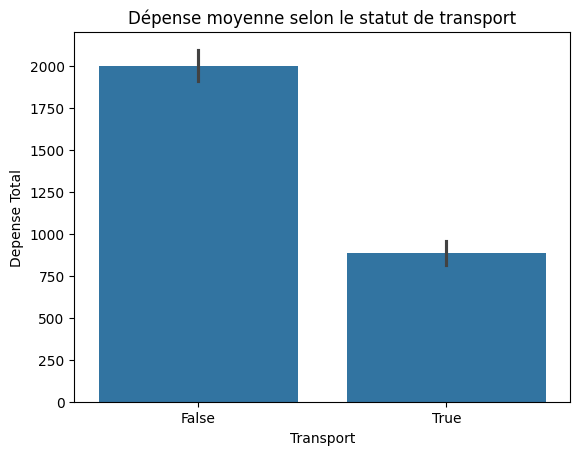

In [159]:
sns.barplot(data=df_titanic, x="Transported", y="TotalSpend")
plt.xlabel("Transport")
plt.ylabel("Depense Total")
plt.title("Dépense moyenne selon le statut de transport")

Text(0.5, 1.0, 'Répartition des passagers en CryoSleep selon le Deck et le Côté')

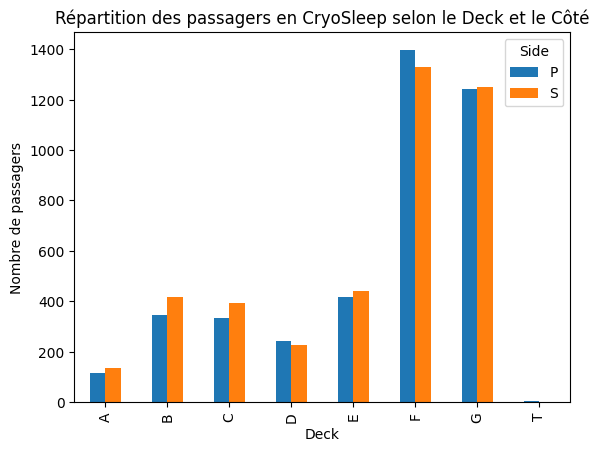

In [160]:
pd.crosstab(df_titanic["Deck"], df_titanic['Side'], values=df_titanic["CryoSleep"], aggfunc='count').plot(kind="bar")

plt.xlabel("Deck")
plt.ylabel("Nombre de passagers")
plt.title("Répartition des passagers en CryoSleep selon le Deck et le Côté")

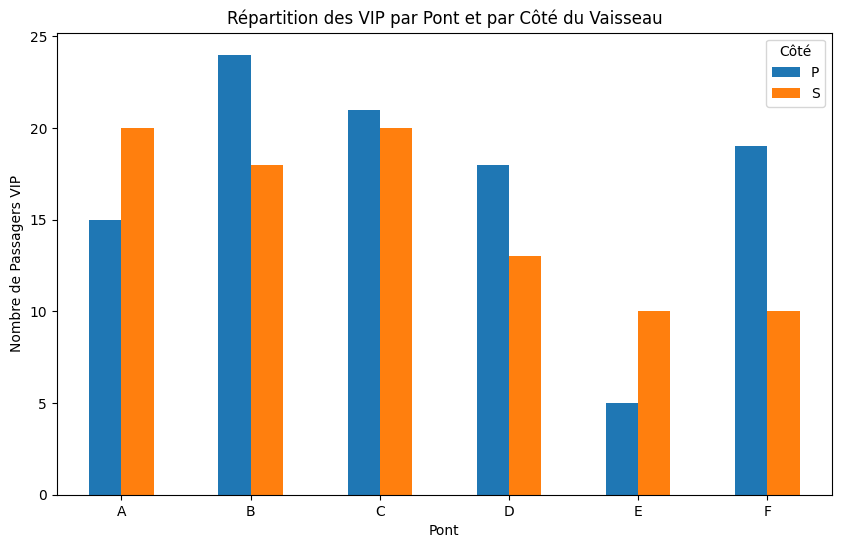

In [161]:
vip_locations = df_titanic[df_titanic['VIP'] == True]
pd.crosstab(vip_locations['Deck'], vip_locations['Side']).plot(kind='bar', figsize=(10, 6))

plt.title('Répartition des VIP par Pont et par Côté du Vaisseau')
plt.xlabel('Pont')
plt.ylabel('Nombre de Passagers VIP')
plt.xticks(rotation=0)
plt.legend(title='Côté')
plt.show()

Ce graphique montre la distribution des passagers VIP à travers les différents ponts Deck et côtés Side du vaisseau. Vous pouvez observer sur quels ponts et côtés les VIP sont majoritairement situés.

In [162]:
df_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,over_15,Transported_numeric,TotalSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,over_15,0,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,over_15,1,736.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,over_15,0,10383.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,over_15,0,5176.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,over_15,1,1091.0


* Nombre de passagers transportés par planète d'origine :

Text(0.5, 0, "Planète d'origine")

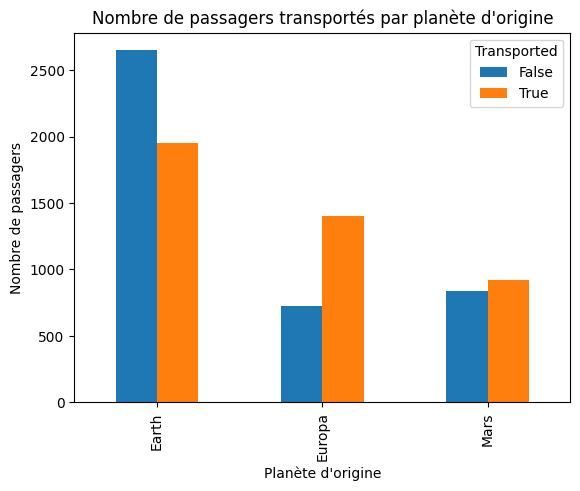

In [163]:
pd.crosstab(df_titanic["HomePlanet"], df_titanic["Transported"]).plot(kind="bar")

plt.title("Nombre de passagers transportés par planète d'origine")
plt.ylabel("Nombre de passagers")
plt.xlabel("Planète d'origine")

* On va decouper le PassengerId en groupe :

In [164]:
df_titanic[['Group', 'GroupMember']] = df_titanic['PassengerId'].str.split('_', expand=True)

In [165]:
display(df_titanic[['PassengerId', 'Group', 'GroupMember']].head(20))

,PassengerId,Group,GroupMember
0,0001_01,0001,01
1,0002_01,0002,01
2,0003_01,0003,01
3,0003_02,0003,02
4,0004_01,0004,01
5,0005_01,0005,01
6,0006_01,0006,01
7,0006_02,0006,02
8,0007_01,0007,01
9,0008_01,0008,01


On a deux nouvelles colonnes : 'Group' pour l'identifiant du groupe et 'GroupMember' pour le numéro du passager au sein de ce groupe.

In [166]:
df_titanic.groupby(['Group']).count()['PassengerId'].sort_values(ascending=False)

,PassengerId
Group,
9081,8
4005,8
8988,8
5133,8
4256,8
...,...
0022,1
0016,1
0015,1


In [167]:
df_titanic.groupby(['Group'])['HomePlanet'].nunique().sort_values(ascending=False)

,HomePlanet
Group,
9280,1
0001,1
0002,1
0003,1
0004,1
...,...
0303,0
0242,0
0251,0


In [168]:
df_titanic.groupby(['Group'])['HomePlanet'].count().sort_values(ascending=False)

,HomePlanet
Group,
9081,8
8988,8
8728,8
5885,8
0984,8
...,...
0303,0
0242,0
0251,0


<Axes: xlabel='PassengerId', ylabel='Percent'>

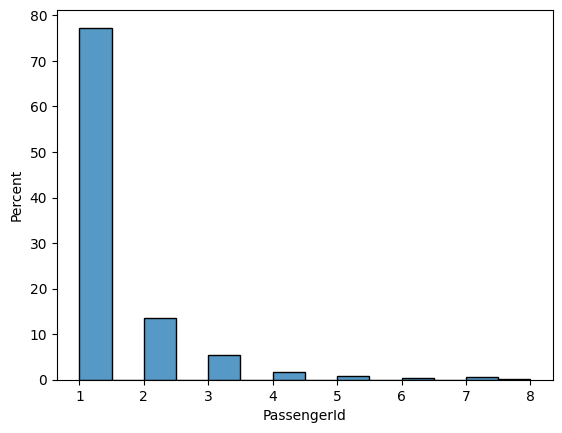

In [169]:
sns.histplot(data=df_titanic.groupby(['Group']).count()['PassengerId'].reset_index(),x='PassengerId',stat='percent')


In [170]:
tutu = df_titanic.merge(df_titanic,on='Group',suffixes=('_1','_2'))
tutu[tutu.Cabin_1 != tutu.Cabin_2][['Group','Cabin_1','Cabin_2']]

,Group,Cabin_1,Cabin_2
9,0006,F/2/S,G/0/S
10,0006,G/0/S,F/2/S
25,0012,NaN,NaN
30,0017,G/0/P,F/6/P
31,0017,F/6/P,G/0/P
...,...,...,...
17641,9231,E/592/P,F/1888/P
17642,9231,E/592/P,F/1888/P
17644,9233,NaN,NaN
17675,9272,G/1507/P,F/1894/P




---



* Transformer CryoSleep en booleen :

In [171]:
df_titanic["CryoSleep"] = df_titanic["CryoSleep"].astype("boolean")

* Transformer VIP en booleen :

In [172]:
df_titanic["VIP"] = df_titanic["VIP"].astype("boolean")

* Transformer over_15 en booleen :

In [173]:
df_titanic['over_15'] = df_titanic['over_15'].map({'over_15': True, '15_or_less': False}).astype("int")

In [174]:
df_titanic = df_titanic.drop(columns=["PassengerId","Cabin","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck","Name","Group","GroupMember","Destination"])
#df_titanic = df_titanic.drop(columns=["Destination"])

In [175]:
df_titanic.head()


,HomePlanet,CryoSleep,Age,VIP,Transported,Deck,Num,Side,over_15,Transported_numeric,TotalSpend
0,Europa,False,39.0,False,False,B,0,P,1,0,0.0
1,Earth,False,24.0,False,True,F,0,S,1,1,736.0
2,Europa,False,58.0,True,False,A,0,S,1,0,10383.0
3,Europa,False,33.0,False,False,A,0,S,1,0,5176.0
4,Earth,False,16.0,False,True,F,1,S,1,1,1091.0


_______

* OneHotEncoding pour HomePlanet :

In [176]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

homeplanet_encoded = encoder.fit_transform(df_titanic[["HomePlanet"]])

* cree un dataframe :

In [177]:
homeplanet_df = pd.DataFrame(homeplanet_encoded,columns=encoder.get_feature_names_out(["HomePlanet"]))

* Ajouter au dataset :

In [178]:
df_titanic = pd.concat([df_titanic, homeplanet_df], axis=1)
df_titanic = df_titanic.drop("HomePlanet", axis=1)

---

* OrdinalEncoder pour Deck :

In [179]:
from sklearn.preprocessing import OrdinalEncoder

deck_encoder = OrdinalEncoder()

df_titanic["Deck_encoded"] = deck_encoder.fit_transform(df_titanic[["Deck"]])

* supprimer la colonne d'origine :

In [180]:
df_titanic = df_titanic.drop("Deck", axis=1)

In [181]:
df_titanic.head(10)

,CryoSleep,Age,VIP,Transported,Num,Side,over_15,Transported_numeric,TotalSpend,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan,Deck_encoded
0,False,39.0,False,False,0,P,1,0,0.0,0.0,1.0,0.0,0.0,1.0
1,False,24.0,False,True,0,S,1,1,736.0,1.0,0.0,0.0,0.0,5.0
2,False,58.0,True,False,0,S,1,0,10383.0,0.0,1.0,0.0,0.0,0.0
3,False,33.0,False,False,0,S,1,0,5176.0,0.0,1.0,0.0,0.0,0.0
4,False,16.0,False,True,1,S,1,1,1091.0,1.0,0.0,0.0,0.0,5.0
5,False,44.0,False,True,0,P,1,1,774.0,1.0,0.0,0.0,0.0,5.0
6,False,26.0,False,True,2,S,1,1,1584.0,1.0,0.0,0.0,0.0,5.0
7,True,28.0,False,True,0,S,1,1,0.0,1.0,0.0,0.0,0.0,6.0
8,False,35.0,False,True,3,S,1,1,1018.0,1.0,0.0,0.0,0.0,5.0
9,True,14.0,False,True,1,P,0,1,0.0,0.0,1.0,0.0,0.0,1.0


* on transforme en 0, 1 :

In [182]:
df_titanic["CryoSleep"] = df_titanic["CryoSleep"].fillna(False).astype(int)

In [183]:
df_titanic["VIP"] = df_titanic["VIP"].fillna(False).astype(int)

In [184]:
df_titanic["over_15"] = df_titanic["over_15"].astype(int)

* On garde que Transported :

In [185]:
df_titanic = df_titanic.drop(columns=["Transported_numeric"])

In [186]:
df_titanic = df_titanic.rename(columns={'Transported': 'Target'})

In [187]:
df_titanic.dropna(inplace=True)

In [188]:
df_titanic

,CryoSleep,Age,VIP,Target,Num,Side,over_15,TotalSpend,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan,Deck_encoded
0,0,39.0,0,False,0,P,1,0.0,0.0,1.0,0.0,0.0,1.0
1,0,24.0,0,True,0,S,1,736.0,1.0,0.0,0.0,0.0,5.0
2,0,58.0,1,False,0,S,1,10383.0,0.0,1.0,0.0,0.0,0.0
3,0,33.0,0,False,0,S,1,5176.0,0.0,1.0,0.0,0.0,0.0
4,0,16.0,0,True,1,S,1,1091.0,1.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,False,98,P,1,8536.0,0.0,1.0,0.0,0.0,0.0
8689,1,18.0,0,False,1499,S,1,0.0,1.0,0.0,0.0,0.0,6.0
8690,0,26.0,0,True,1500,S,1,1873.0,1.0,0.0,0.0,0.0,6.0
8691,0,32.0,0,False,608,S,1,4637.0,0.0,1.0,0.0,0.0,4.0


In [199]:
df_titanic.isnull().sum()

,0
CryoSleep,0
Age,0
VIP,0
Target,0
Num,0
Side,0
over_15,0
TotalSpend,0
HomePlanet_Earth,0
HomePlanet_Europa,0


In [203]:
df_titanic_ft = df_titanic.copy()

In [241]:
# 1. On repart sur une base propre
df_titanic_ft = df_titanic.copy().reset_index(drop=True)

# 2. Ajout des colonnes de dépenses individuelles depuis l'original (train.csv)
# On utilise l'index de df_titanic pour aligner correctement les données
df_raw = pd.read_csv('train.csv')
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spend_cols:
    df_titanic_ft[col] = df_raw.loc[df_titanic.index, col].values
    df_titanic_ft[col] = df_titanic_ft[col].fillna(0)

# 3. Encodage de 'Side' (P/S)
side_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
side_encoded = side_encoder.fit_transform(df_titanic_ft[['Side']].fillna('Unknown'))
side_df = pd.DataFrame(side_encoded, columns=side_encoder.get_feature_names_out(['Side']), index=df_titanic_ft.index)
df_titanic_ft = pd.concat([df_titanic_ft, side_df], axis=1)

# 4. Nettoyage final : suppression de Side original et TotalSpend
# On ne traite plus 'Destination'
df_titanic_ft = df_titanic_ft.drop(columns=['Side', 'TotalSpend'], errors='ignore')

# 5. Conversion des types pour XGBoost
df_titanic_ft['Num'] = pd.to_numeric(df_titanic_ft['Num'], errors='coerce').fillna(0).astype(int)
df_titanic_ft['Age'] = df_titanic_ft['Age'].fillna(df_titanic_ft['Age'].median())

print("Nouvelles colonnes :", df_titanic_ft.columns.tolist())
print("Total NaN :", df_titanic_ft.isnull().sum().sum())
display(df_titanic_ft.head())

Nouvelles colonnes : ['CryoSleep', 'Age', 'VIP', 'Target', 'Num', 'over_15', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_nan', 'Deck_encoded', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Side_P', 'Side_S']
Total NaN : 0


,CryoSleep,Age,VIP,Target,Num,over_15,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan,Deck_encoded,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Side_P,Side_S
0,0,39.0,0,False,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,24.0,0,True,0,1,1.0,0.0,0.0,0.0,5.0,109.0,9.0,25.0,549.0,44.0,0.0,1.0
2,0,58.0,1,False,0,1,0.0,1.0,0.0,0.0,0.0,43.0,3576.0,0.0,6715.0,49.0,0.0,1.0
3,0,33.0,0,False,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0.0,1.0
4,0,16.0,0,True,1,1,1.0,0.0,0.0,0.0,5.0,303.0,70.0,151.0,565.0,2.0,0.0,1.0


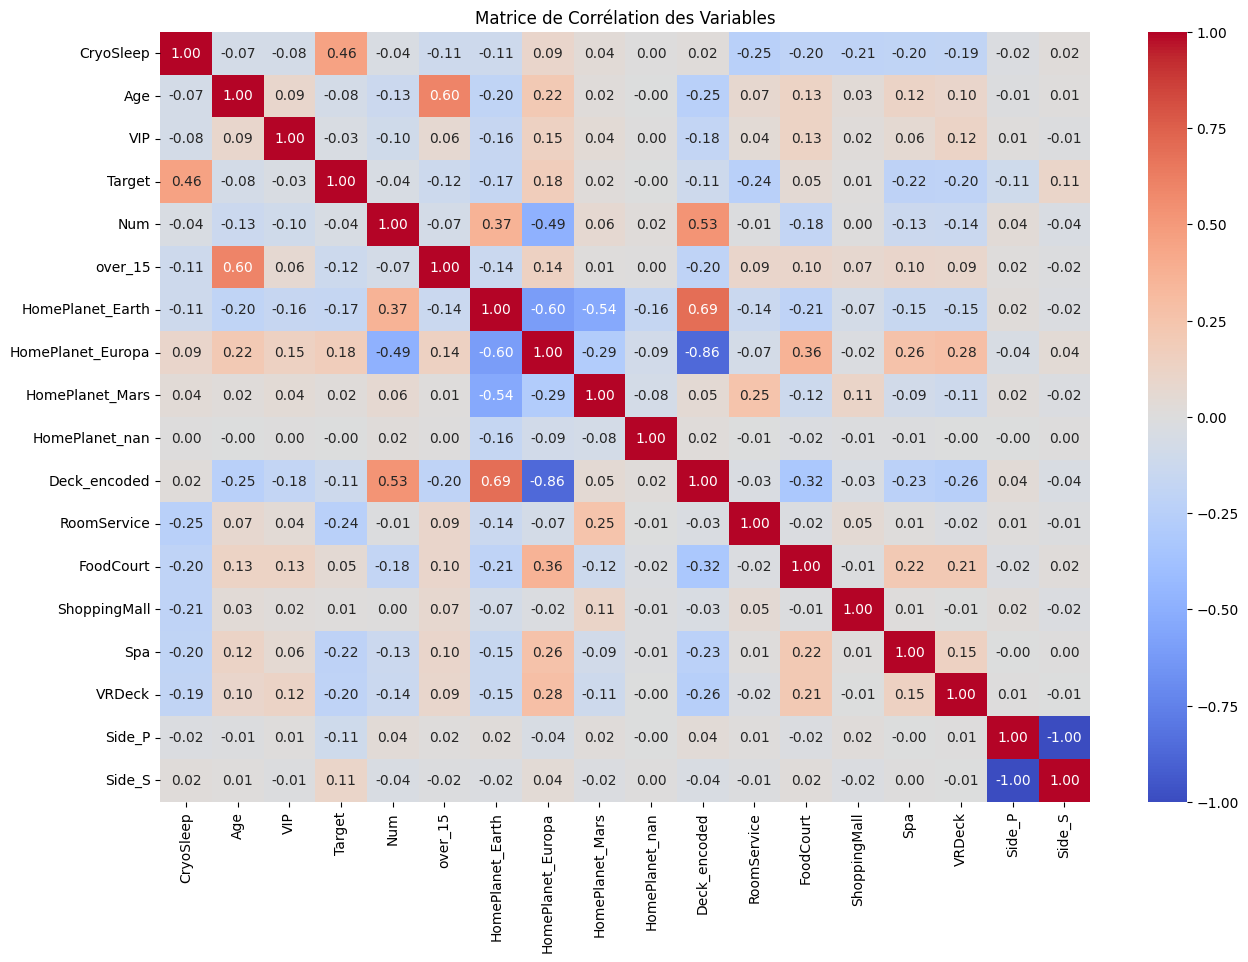

In [242]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_titanic_ft.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation des Variables')
plt.show()

In [243]:
df_titanic_ft.head()

,CryoSleep,Age,VIP,Target,Num,over_15,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan,Deck_encoded,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Side_P,Side_S
0,0,39.0,0,False,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,24.0,0,True,0,1,1.0,0.0,0.0,0.0,5.0,109.0,9.0,25.0,549.0,44.0,0.0,1.0
2,0,58.0,1,False,0,1,0.0,1.0,0.0,0.0,0.0,43.0,3576.0,0.0,6715.0,49.0,0.0,1.0
3,0,33.0,0,False,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0.0,1.0
4,0,16.0,0,True,1,1,1.0,0.0,0.0,0.0,5.0,303.0,70.0,151.0,565.0,2.0,0.0,1.0


In [206]:
df_titanic_ft.head()

,CryoSleep,Age,VIP,Target,Num,over_15,TotalSpend,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan,Deck_encoded,Side_P,Side_S
0,0,39.0,0,False,0,1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0,24.0,0,True,0,1,736.0,1.0,0.0,0.0,0.0,5.0,0.0,1.0
2,0,58.0,1,False,0,1,10383.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0,33.0,0,False,0,1,5176.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0,16.0,0,True,1,1,1091.0,1.0,0.0,0.0,0.0,5.0,0.0,1.0


## Entrainement avec RandomForest :

* Séparer les variables X et y :

In [244]:
# On réactualise X et y après la correction du type de 'Num'
X = df_titanic_ft.drop("Target", axis=1)
y = df_titanic_ft["Target"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

* Separer train et test :

In [245]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---

On garde 80% pour entrainer et 20% pour test

* Importer RandomForest et creer le modele :

In [246]:
from sklearn.ensemble import RandomForestClassifier

In [247]:
model = RandomForestClassifier(random_state=42)

In [248]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [249]:
print (model.score(X_train, y_train))
print (model.score(X_test, y_test))


0.9996994740796393
0.7836538461538461


In [250]:
from sklearn.model_selection import GridSearchCV

# Définition des paramètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialisation du GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

grid_search.fit(X_train, y_train)

# Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score de validation : {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
print(f"Score final sur le Test Set : {best_model.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Meilleur score de validation : 0.8072
Score final sur le Test Set : 0.7915


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Score XGBoost sur Test: 0.7897


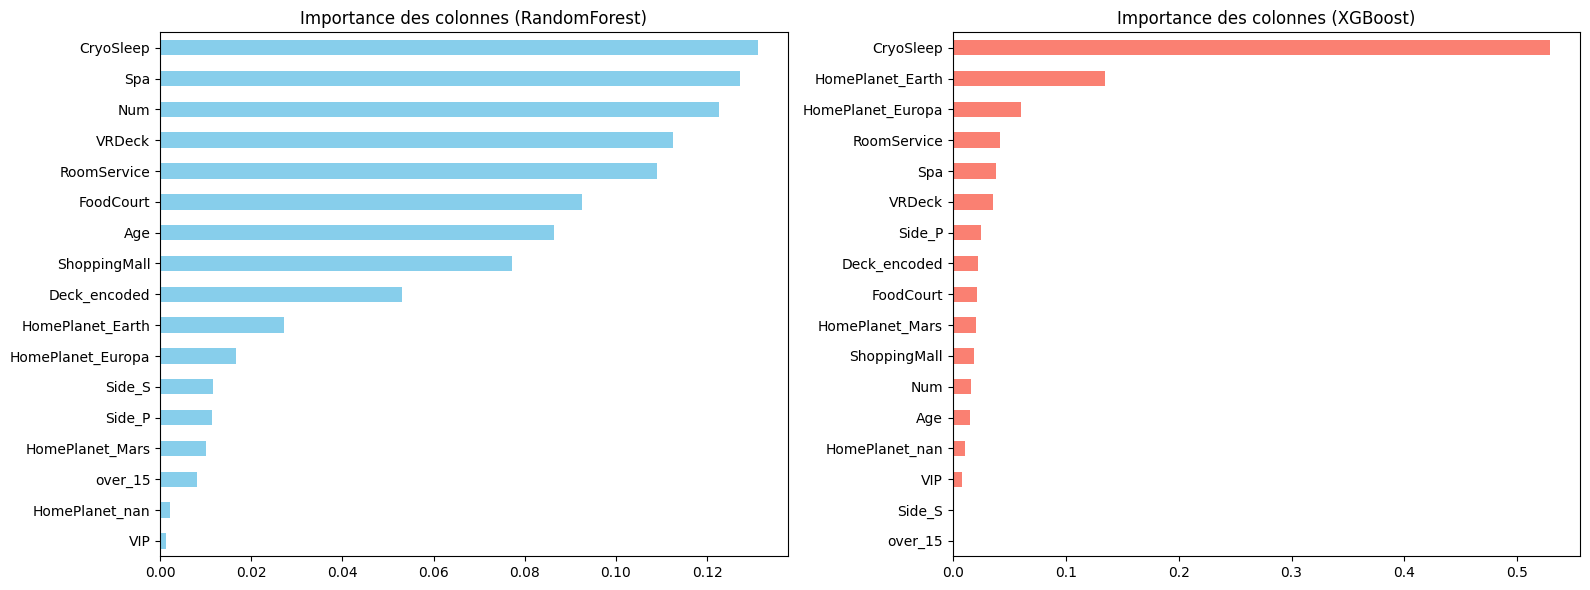

In [251]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuration et entraînement de XGBoost avec GridSearchCV
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42), xgb_param_grid, cv=5, n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"Score XGBoost sur Test: {best_xgb.score(X_test, y_test):.4f}")

# 2. Visualisation des Features Importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Importance pour RandomForest
rf_importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Importance des colonnes (RandomForest)')

# Importance pour XGBoost
xgb_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importance.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Importance des colonnes (XGBoost)')

plt.tight_layout()
plt.show()

In [283]:
from sklearn.metrics import classification_report

# Prédictions
y_pred_rf = best_model.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("--- Rapport de Classification : RandomForest ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Rapport de Classification : XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

--- Rapport de Classification : RandomForest ---
              precision    recall  f1-score   support

       False       0.79      0.80      0.80       853
        True       0.79      0.78      0.79       811

    accuracy                           0.79      1664
   macro avg       0.79      0.79      0.79      1664
weighted avg       0.79      0.79      0.79      1664


--- Rapport de Classification : XGBoost ---
              precision    recall  f1-score   support

       False       0.82      0.76      0.79       853
        True       0.77      0.82      0.79       811

    accuracy                           0.79      1664
   macro avg       0.79      0.79      0.79      1664
weighted avg       0.79      0.79      0.79      1664



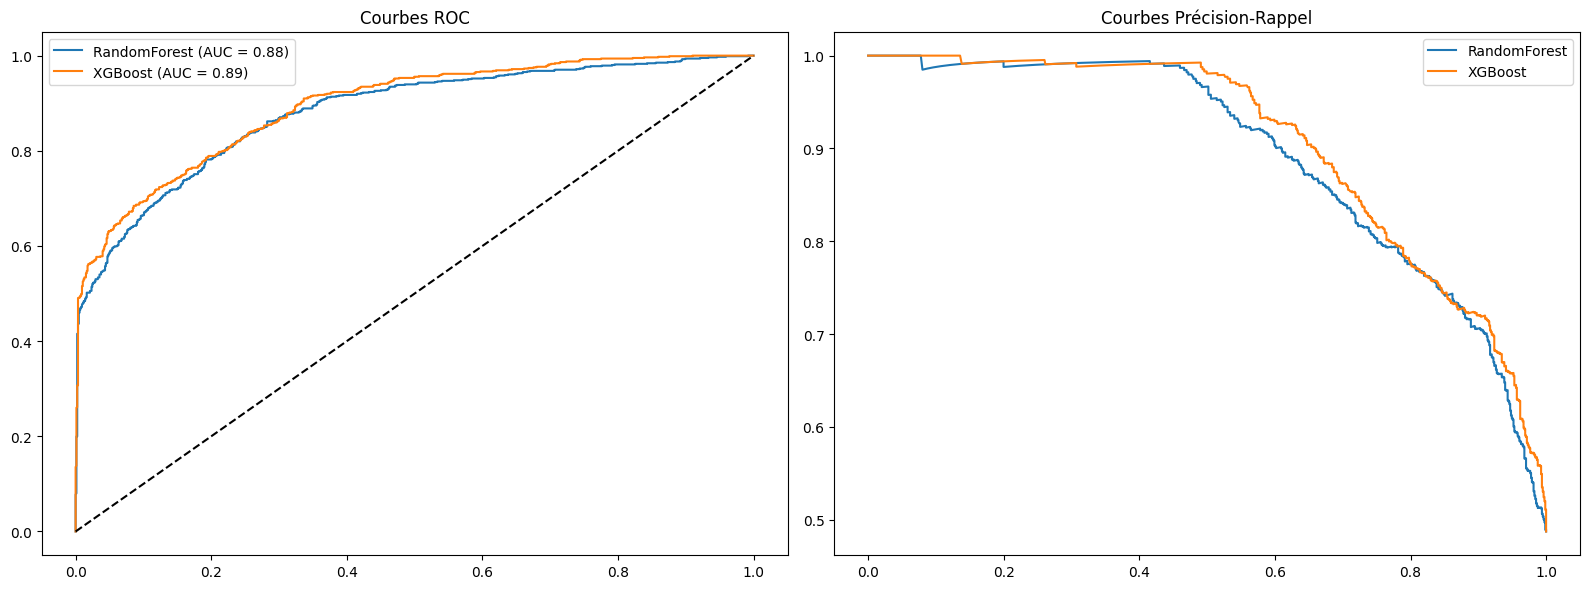

In [272]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calcul des probabilités pour les courbes
y_probs_rf = best_model.predict_proba(X_test)[:, 1]
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Configuration de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)

ax1.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('Taux de Faux Positifs')
ax1.set_ylabel('Taux de Vrais Positifs')
ax1.set_title('Courbes ROC')
ax1.legend(loc='lower right')

# 2. Courbe Précision-Rappel
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_probs_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)

ax2.plot(rec_rf, prec_rf, label=f'RandomForest (AP = {average_precision_score(y_test, y_probs_rf):.2f})')
ax2.plot(rec_xgb, prec_xgb, label=f'XGBoost (AP = {average_precision_score(y_test, y_probs_xgb):.2f})')
ax2.set_xlabel('Rappel (Recall)')
ax2.set_ylabel('Précision')
ax2.set_title('Courbes Précision-Rappel')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

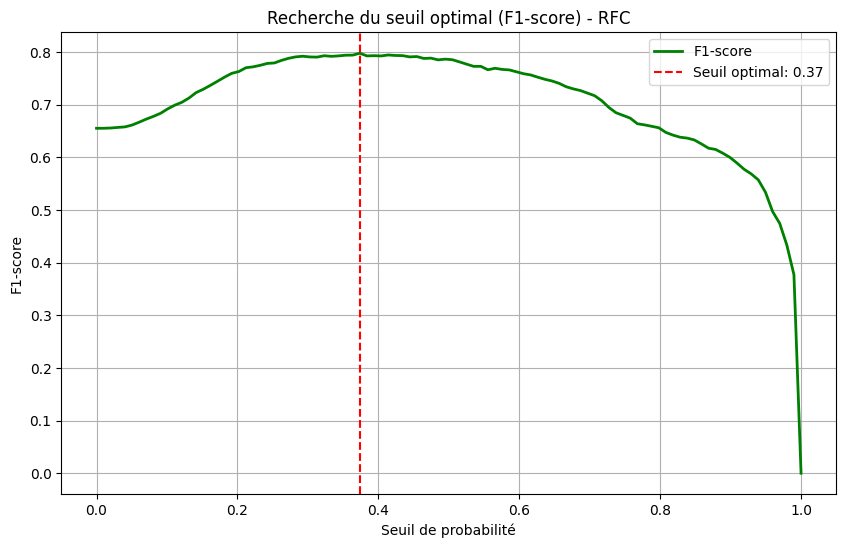

Le seuil qui maximise le F1-score est 0.37 avec un score de 0.7979


In [277]:
import numpy as np
from sklearn.metrics import f1_score

# Nous allons utiliser les probabilités de notre meilleur modèle (RandomForest)
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test, y_probs_rf > t) for t in thresholds]

# Trouver le seuil qui maximise le F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-score', color='green', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil optimal: {best_threshold:.2f}')
plt.title('Recherche du seuil optimal (F1-score) - RFC')
plt.xlabel('Seuil de probabilité')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.show()

print(f"Le seuil qui maximise le F1-score est {best_threshold:.2f} avec un score de {best_f1:.4f}")

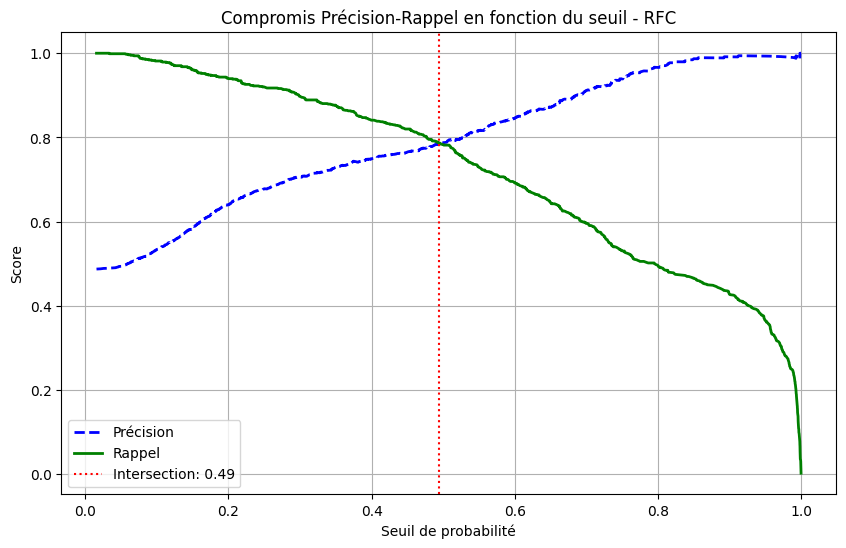

In [278]:
from sklearn.metrics import precision_recall_curve

# Calcul de la précision et du rappel pour différents seuils
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precision[:-1], 'b--', label='Précision', lw=2)
plt.plot(thresholds_pr, recall[:-1], 'g-', label='Rappel', lw=2)

# Trouver le point d'intersection approximatif
idx = np.argwhere(np.diff(np.sign(precision - recall))).flatten()
if len(idx) > 0:
    plt.axvline(thresholds_pr[idx[0]], color='red', linestyle=':', label=f'Intersection: {thresholds_pr[idx[0]]:.2f}')

plt.title('Compromis Précision-Rappel en fonction du seuil - RFC')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [279]:
from sklearn.metrics import classification_report

# Application du seuil d'équilibre identifié (0.49)
custom_threshold = 0.49
y_pred_custom = (y_probs_rf >= custom_threshold)

print(f"--- Rapport de Classification avec Seuil = {custom_threshold} ---")
print(classification_report(y_test, y_pred_custom))

# Comparaison avec le score précédent
print(f"Ancien F1-score (seuil 0.5): 0.73")
from sklearn.metrics import f1_score
print(f"Nouveau F1-score (seuil 0.43): {f1_score(y_test, y_pred_custom):.4f}")

--- Rapport de Classification avec Seuil = 0.49 ---
              precision    recall  f1-score   support

       False       0.80      0.79      0.80       853
        True       0.78      0.79      0.79       811

    accuracy                           0.79      1664
   macro avg       0.79      0.79      0.79      1664
weighted avg       0.79      0.79      0.79      1664

Ancien F1-score (seuil 0.5): 0.73
Nouveau F1-score (seuil 0.43): 0.7870


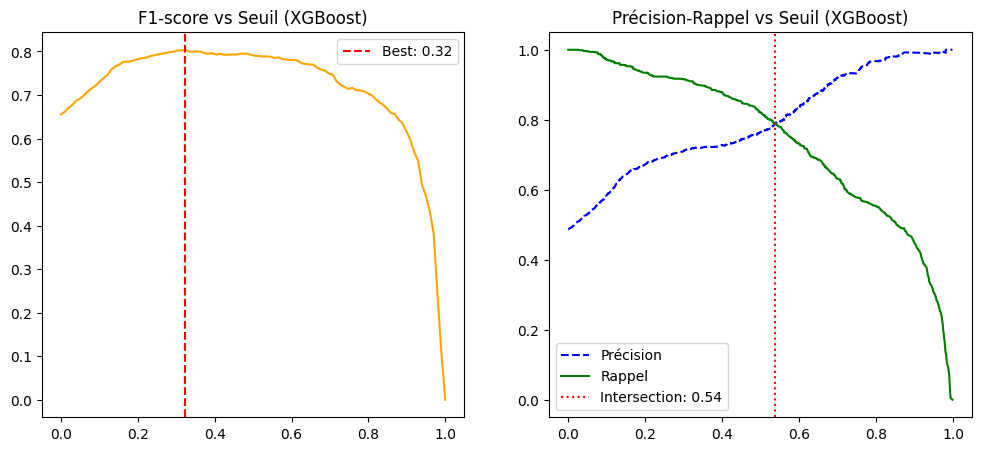

Le seuil optimal pour XGBoost est 0.32


In [282]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve

# Recherche du seuil optimal pour le F1-score
thresholds = np.linspace(0, 1, 100)
f1_scores_xgb = [f1_score(y_test, y_probs_xgb > t) for t in thresholds]
best_threshold_xgb = thresholds[np.argmax(f1_scores_xgb)]

# Graphique F1-score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores_xgb, color='orange')
plt.axvline(best_threshold_xgb, color='red', linestyle='--', label=f'Best: {best_threshold_xgb:.2f}')
plt.title('F1-score vs Seuil (XGBoost)')
plt.legend()

# Graphique Compromis Précision-Rappel
precision_xgb, recall_xgb, thresholds_xgb_pr = precision_recall_curve(y_test, y_probs_xgb)
plt.subplot(1, 2, 2)
plt.plot(thresholds_xgb_pr, precision_xgb[:-1], 'b--', label='Précision')
plt.plot(thresholds_xgb_pr, recall_xgb[:-1], 'g-', label='Rappel')

# Ajout du trait à l'intersection
idx_inter = np.argwhere(np.diff(np.sign(precision_xgb - recall_xgb))).flatten()
if len(idx_inter) > 0:
    plt.axvline(thresholds_xgb_pr[idx_inter[0]], color='red', linestyle=':', label=f'Intersection: {thresholds_xgb_pr[idx_inter[0]]:.2f}')

plt.title('Précision-Rappel vs Seuil (XGBoost)')
plt.legend()
plt.show()

print(f"Le seuil optimal pour XGBoost est {best_threshold_xgb:.2f}")

In [292]:
from sklearn.metrics import classification_report

# Application du seuil d'équilibre identifié (0.54)
custom_threshold = 0.54
y_pred_custom = (y_probs_rf >= custom_threshold)

print(f"--- Rapport de Classification avec Seuil = {custom_threshold} ---")
print(classification_report(y_test, y_pred_xgb))

# Comparaison avec le score précédent
print(f"Ancien F1-score (seuil 0.5): 0.73")
from sklearn.metrics import f1_score
print(f"Nouveau F1-score (seuil 0.43): {f1_score(y_test, y_pred_xgb):.4f}")

--- Rapport de Classification avec Seuil = 0.54 ---
              precision    recall  f1-score   support

       False       0.82      0.76      0.79       853
        True       0.77      0.82      0.79       811

    accuracy                           0.79      1664
   macro avg       0.79      0.79      0.79      1664
weighted avg       0.79      0.79      0.79      1664

Ancien F1-score (seuil 0.5): 0.73
Nouveau F1-score (seuil 0.43): 0.7917


In [294]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score
import pandas as pd

# Configuration des seuils optimaux identifiés
threshold_rf = 0.49
threshold_xgb = 0.54

# Prédictions basées sur les seuils
y_pred_rf_final = (y_probs_rf >= threshold_rf)
y_pred_xgb_final = (y_probs_xgb >= threshold_xgb)

def get_metrics(name, y_true, y_pred, y_probs):
    return {
        "Modèle": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_probs),
        "F1-Score": f1_score(y_true, y_pred)
    }

# Création du tableau comparatif
results = [
    get_metrics("RandomForest (0.49)", y_test, y_pred_rf_final, y_probs_rf),
    get_metrics("XGBoost (0.32)", y_test, y_pred_xgb_final, y_probs_xgb)
]

print("--- SYNTHÈSE DES PERFORMANCES ---")
display(pd.DataFrame(results))

print("\n--- DÉTAILS RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf_final))

print("\n--- DÉTAILS XGBOOST ---")
print(classification_report(y_test, y_pred_xgb_final))

--- SYNTHÈSE DES PERFORMANCES ---


,Modèle,Accuracy,ROC-AUC,F1-Score
0,RandomForest (0.49),0.791466,0.880194,0.786986
1,XGBoost (0.32),0.796274,0.893685,0.790611



--- DÉTAILS RANDOM FOREST ---
              precision    recall  f1-score   support

       False       0.80      0.79      0.80       853
        True       0.78      0.79      0.79       811

    accuracy                           0.79      1664
   macro avg       0.79      0.79      0.79      1664
weighted avg       0.79      0.79      0.79      1664


--- DÉTAILS XGBOOST ---
              precision    recall  f1-score   support

       False       0.80      0.80      0.80       853
        True       0.79      0.79      0.79       811

    accuracy                           0.80      1664
   macro avg       0.80      0.80      0.80      1664
weighted avg       0.80      0.80      0.80      1664



In [ ]:
import joblib

# Sauvegarde du modèle XGBoost
model_filename = 'titanic_model.pkl'
joblib.dump(best_xgb, model_filename)

print(f"Modèle sauvegardé sous : {model_filename}")

Modèle sauvegardé sous : spaceship_titanic_xgb_model.pkl
Prêt pour de nouvelles prédictions avec le seuil 0.54 !


In [ ]:
import joblib

joblib.dump(model, "titanic_model.pkl")